# Import libraries

In [2]:
import stim
import pyzx
import matplotlib.pyplot as plt
import networkx as nx
from ugr import *

# Define some examples of stabilizer codes 


In [3]:
def display_code(name, stabilizers):
    u = stabilizers_to_UGR(stabilizers)
    G = nx.Graph()

    adj_list = u.adj

    for x in range(len(adj_list)):
        if x in u.inputs:
            print(x)
            G.add_node(x, color="#4e598c")
        else:
            G.add_node(x, color="#ff8c42")

    for u, neighbors in enumerate(adj_list):
        for v in neighbors:
            G.add_edge(u, v)

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=144)
    node_colors = [G.nodes[n]['color'] for n in G.nodes()]


    nx.draw(G, pos, 
            node_color=node_colors, 
            node_size=600, 
            font_weight='bold')

    # plt.title("Graph from Index-Based Adjacency List")
    plt.savefig(f"plots/{name}")
    plt.show()





## Steane code

0


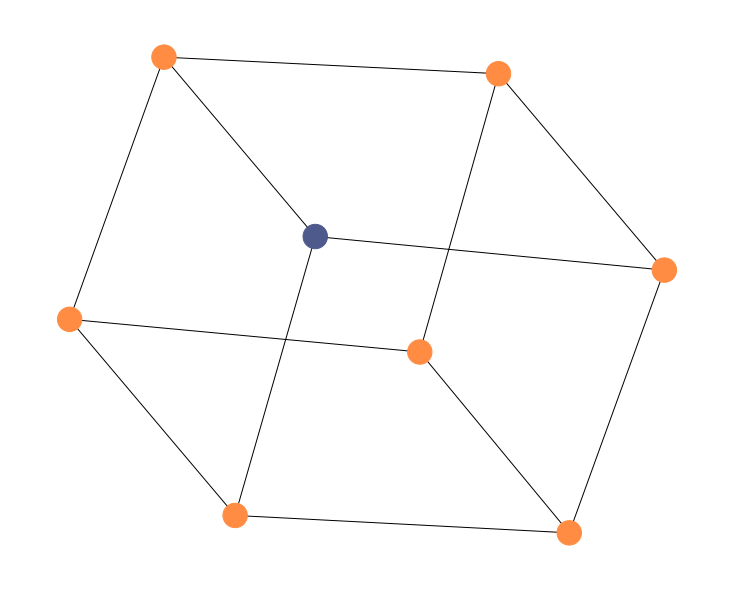

In [5]:
display_code("steane", example_code_stabilizers("steane"))

## Shor code

0


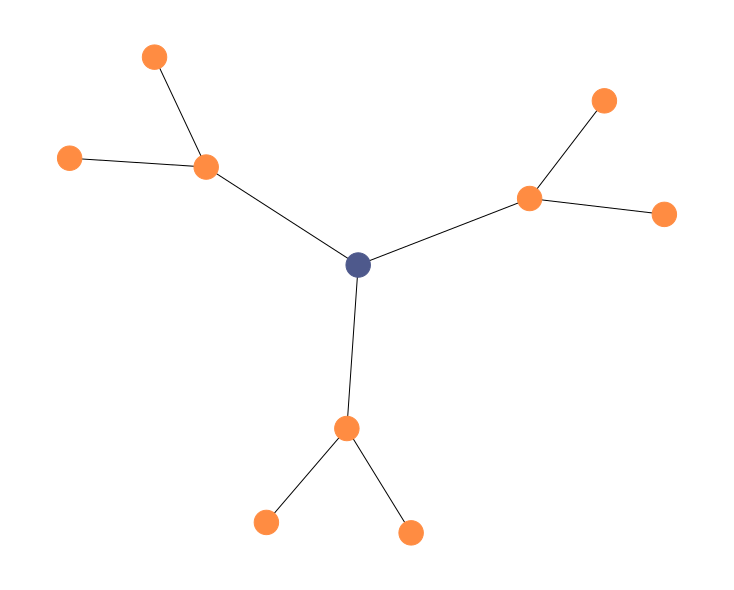

In [7]:
display_code("shor",example_code_stabilizers("shor"))

## 5 qubit code

0


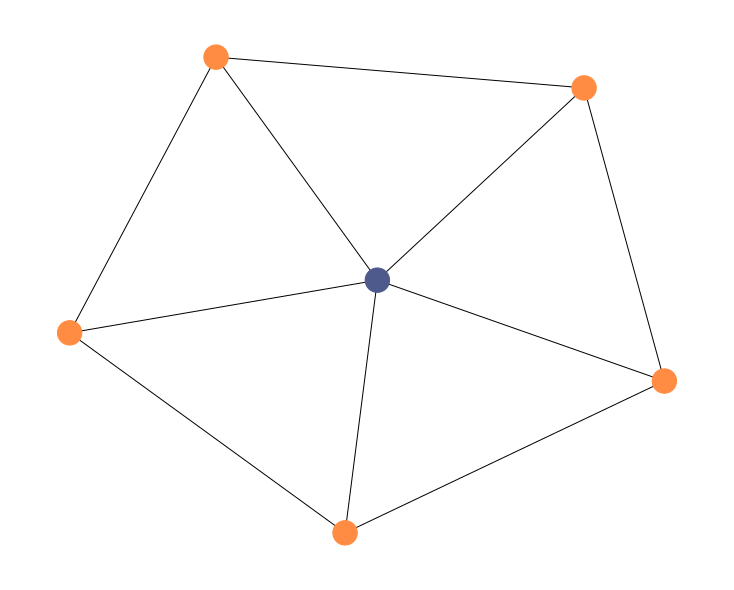

In [12]:
display_code("five_qubit",example_code_stabilizers("five_qubit"))

## Rotated surface code 3x3

0


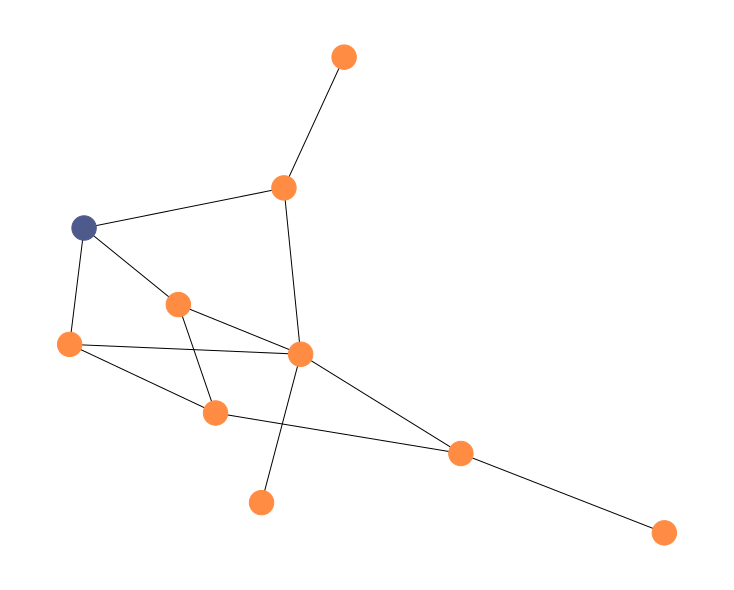

In [13]:
display_code("rotated",example_code_stabilizers("rotated3x3"))

## Toric Code 2x2

0
1


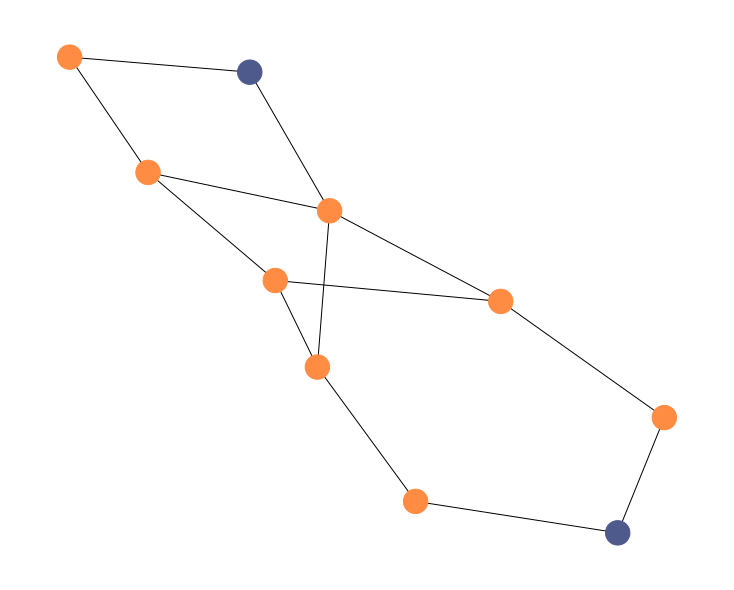

In [14]:
display_code("toric2x2", example_code_stabilizers("toric2x2"))

## Toric Code 3x3

0
1


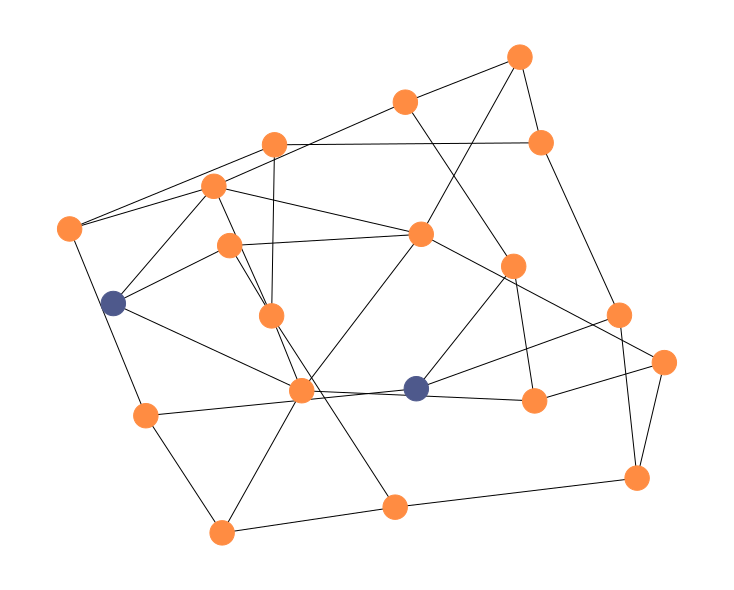

In [15]:
display_code("toric3x3",example_code_stabilizers("toric3x3"))

## Shor code: steb by step

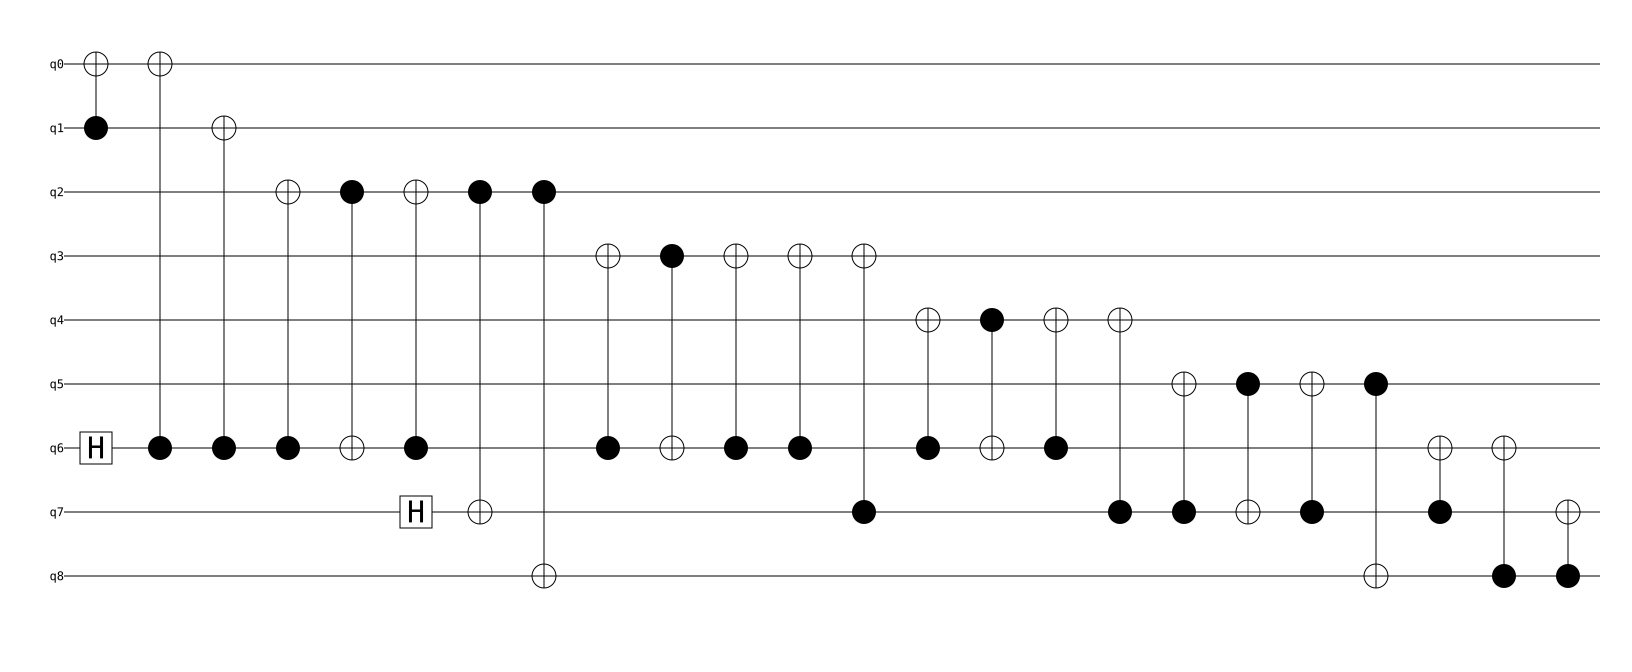

In [17]:
stabilizer_shor = example_code_stabilizers("shor") 
n = len(stabilizer_shor[0])
k = n - len(stabilizer_shor)

stabilizers = [stim.PauliString(x) for x in stabilizer_shor]

tableau = stim.Tableau.from_stabilizers(stabilizers, allow_underconstrained=True)

shor_encoder = tableau.to_circuit(method = "elimination")

shor_encoder.diagram("timeline-svg")

In [20]:
shor_qasm = shor_encoder.to_qasm(open_qasm_version=3)
pyzx_shor = pyzx.Circuit.from_qasm(shor_qasm).to_graph()
input_state =  "0"*(n - k)  + "/"*k
pyzx_shor.apply_state(input_state)
pyzx.draw(pyzx_shor)

In [21]:
inputs = list(pyzx_shor.inputs())
shor_graph_state = GraphState(pyzx_shor)
pyzx.draw(shor_graph_state.get_graph())

In [22]:
shor_graph_state.to_canonical_form()
pyzx.draw(shor_graph_state.get_graph())

In [23]:
zxcf = graph_state_to_ZXCF(shor_graph_state, inputs)
pyzx.draw(zxcf.graph)